In [4]:
import numpy as np
import ase
from ase.build import bulk, surface
from ase import Atoms
from ase.visualize import view
from ase.io import write
from ase.build import bulk, surface
from dscribe.descriptors import SOAP
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.manifold import TSNE
from sklearn.cluster import MiniBatchKMeans, SpectralClustering, DBSCAN
from matplotlib import cm
from matplotlib.colors import ListedColormap

In [ ]:
# ---------- 1. Build a Si(111) slab ----------

a = 5.431  # Si diamond lattice parameter (Å)
bulk_si = bulk("Si", "diamond", a=a)

# reasonably thick slab
slab = surface(bulk_si, (1, 1, 1), layers=12, vacuum=15.0)
slab.center(axis=2)

# replicate in-plane a bit
slab = slab.repeat((4, 4, 1))
cell = slab.get_cell()
print("Original slab atoms:", len(slab))

# ---------- 2. Split into two grains across x ----------

# We’ll cut at the middle of the original cell in x
mid_x = cell[0, 0] / 2.0

pos = slab.get_positions()
left_mask = pos[:, 0] <= mid_x
right_mask = ~left_mask

left = slab[left_mask]
right = slab[right_mask]

# ---------- 3. Make a symmetric tilt around z ----------

theta = 10  # total misorientation angle in degrees (small for minimal strain)

# Center of rotation: middle of the original cell
rot_center = [cell[0, 0] / 2.0, cell[1, 1] / 2.0, cell[2, 2] / 2.0]

left.rotate(+theta / 2.0, "z", center=rot_center)
right.rotate(-theta / 2.0, "z", center=rot_center)

# ---------- 4. Bring the two grains together along x ----------

# Move right grain so that it sits next to the left grain
left_xmax = left.get_positions()[:, 0].max()
right_xmin = right.get_positions()[:, 0].min()

# Small gap (0.5 Å) to avoid crazy overlaps before relaxation
shift_x = (left_xmax - right_xmin) + 0.5
right.translate([shift_x, 0.0, 0.0])

# Combine grains
gb = left + right

# ---------- 5. Define a new cell with vacuum along x ----------

# Get bounding box of the combined system
pos_gb = gb.get_positions()
x_min, x_max = pos_gb[:, 0].min(), pos_gb[:, 0].max()
Lx = (x_max - x_min) + 10.0  # add 10 Å vacuum in x

# Shift so that atoms are roughly centered in the new cell
gb.translate([-x_min + 5.0, 0.0, 0.0])

# Build new cell: keep original y,z dimensions
new_cell = cell.copy()
new_cell[0, :] = [Lx, 0.0, 0.0]  # x axis length only
gb.set_cell(new_cell)

# Non-periodic along x, periodic in y,z
gb.set_pbc([False, True, True])

print("GB atoms:", len(gb))

# Optional: write for visualization
write("si111_gb.xyz", gb)
write("si111_gb.vasp", gb, vasp5=True, direct=True)

# ---------- 6. SOAP descriptor on a plane through the GB ----------

# Reuse SOAP, but system is now non-periodic in x → use periodic=False
soap = SOAP(
    sigma=0.5,
    n_max=8,
    l_max=8,
    weighting={"function": "poly", "r0": 5.0, "m": 2, "c": 1, "d": 1},
    species=["Si"],
    periodic=False,
)

cell = gb.get_cell()
cell_mat = cell.array

# Probe plane: choose a z in the middle of the slab (no surface needed here)
z_mid = (pos_gb[:, 2].min() + pos_gb[:, 2].max()) / 2.0

# Convert that to scaled z
top_z_scaled = z_mid / cell_mat[2, 2]

n = 100
range_xy = np.linspace(0.0, 1.0, n)
x, y, z = np.meshgrid(range_xy, range_xy, [top_z_scaled])
positions_scaled = np.vstack([x.ravel(), y.ravel(), z.ravel()]).T

# scaled -> Cartesian
positions_cart = positions_scaled @ cell_mat

# Compute SOAP on the probe grid
D = soap.create(gb, positions_cart)

# Save for later
np.save("r_gb.npy", positions_cart)
np.save("D_gb.npy", D)


Original slab atoms: 384
GB atoms: 384


In [8]:
from ase.calculators.lammpsrun import LAMMPS
from ase.constraints import FixAtoms
from ase.optimize import FIRE
from ase.io import write

parameters = {
    "pair_style": "sw",
    "pair_coeff": ["* * Si.sw Si"],
    "mass": ["1 28.0855"],
}

files = ["Si.sw"]

calc = LAMMPS(
    files=files,
    specorder=["Si"],
    command="lmp_serial",
    **parameters,          # <- unpack, don’t pass as 'parameters='
)

gb.calc = calc    # or gb.set_calculator(calc)


gb.set_calculator(calc)

pos = gb.get_positions()
x = pos[:, 0]
z = pos[:, 2]

# Grain boundary plane is roughly in the middle of x
x_mid = 0.5 * (x.min() + x.max())
dx = np.abs(x - x_mid)

# Example heuristic: fix atoms more than 12 Å from the GB plane
# and the bottom ~3 Å in z
fix_mask = (dx > 12.0) | (z < (z.min() + 3.0))

constraint = FixAtoms(mask=fix_mask)
gb.set_constraint(constraint)

dyn = FIRE(gb, trajectory="gb_relax.traj", logfile="gb_relax.log")

# relax until max force < 0.02 eV/Å
dyn.run(fmax=0.02)

# save relaxed structure
write("si111_gb_relaxed.xyz", gb)
write("si111_gb_relaxed.vasp", gb, vasp5=True, direct=True)

print("Max force after relaxation:", np.abs(gb.get_forces()).max())

cell = gb.get_cell().array
pos_gb = gb.get_positions()

# e.g. probe mid-plane in z again
z_mid = 0.5 * (pos_gb[:, 2].min() + pos_gb[:, 2].max())
top_z_scaled = z_mid / cell[2, 2]

n = 100
range_xy = np.linspace(0.0, 1.0, n)
x, y, z = np.meshgrid(range_xy, range_xy, [top_z_scaled])
positions_scaled = np.vstack([x.ravel(), y.ravel(), z.ravel()]).T
positions_cart = positions_scaled @ cell

D = soap.create(gb, positions_cart)
np.save("r_gb_relaxed.npy", positions_cart)
np.save("D_gb_relaxed.npy", D)



/var/folders/tp/vst66z216pz94zn6s3ft55kw0000gn/T/ipykernel_14051/4178131910.py:24: FutureWarning: Please use atoms.calc = calc
  gb.set_calculator(calc)
/Users/dawsonren/miniconda3/envs/chem-calorine/lib/python3.11/site-packages/ase/calculators/lammpsrun.py:320: UserWarning: semi-periodic ASE cell detected - translation to proper LAMMPS input cell might fail
  warnings.warn(
/Users/dawsonren/miniconda3/envs/chem-calorine/lib/python3.11/site-packages/ase/calculators/lammpsrun.py:320: UserWarning: semi-periodic ASE cell detected - translation to proper LAMMPS input cell might fail
  warnings.warn(


Max force after relaxation: 0.015610219707885849


/var/folders/tp/vst66z216pz94zn6s3ft55kw0000gn/T/ipykernel_14051/2852000368.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = cm.get_cmap('viridis', n_clusters)


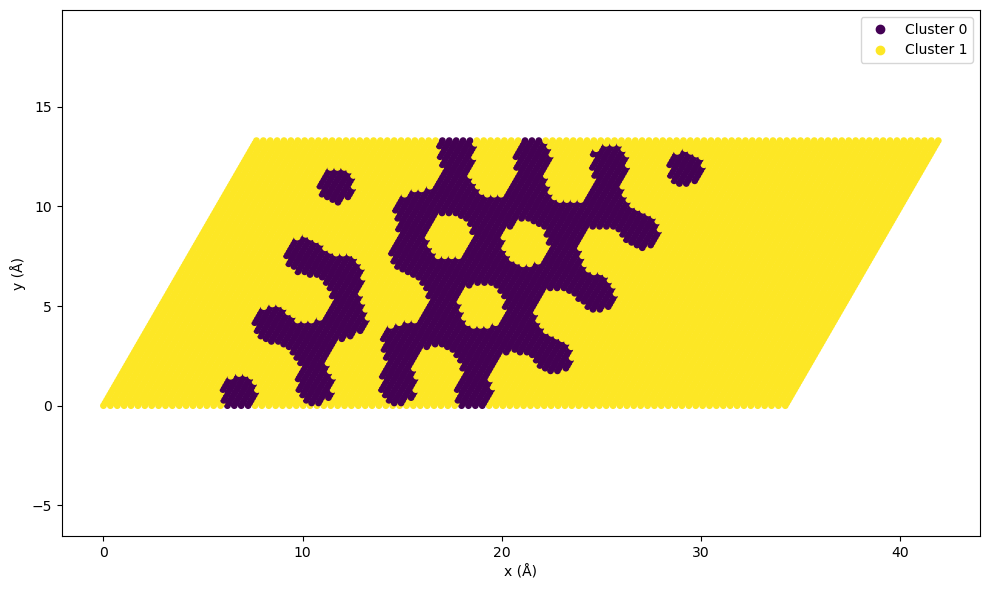

In [9]:
# Load the dataset
D = np.load("D_gb.npy")
r = np.load("r_gb.npy")
n_samples, n_features = D.shape

# Split into different cluster with K-means
n_clusters = 2
model = MiniBatchKMeans(n_clusters=n_clusters, random_state=42)
model.fit(D)
labels = model.labels_

# Visualize clusters in a plot
x = r[:, 0]
y = r[:, 1]
colours = cm.get_cmap('viridis', n_clusters)
classes = ["Cluster {}".format(i) for i in range(n_clusters)]
fig, ax = plt.subplots(1,1, figsize=(10, 6))
ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.axis('equal')
scatter = ax.scatter(x, y, c=labels, cmap=colours, s=15)
ax.legend(handles=scatter.legend_elements()[0], labels=classes)
fig.tight_layout()
plt.show()

In [ ]:
# There are 10000 features for each atom. Many of the features are just constant zeros, so we can remove those.
# Otherwise, seems to be dense. 